# Extreme heat evaluation over Europe

By: Alejandro Fernandez

Date: 11-05-2026

This notebook documents the necessary steps and describes assumptions made in order to describe extreme heat events across Europe.


## Introduction/context

The purpose of this notebook is to analyze daily maximum temperature geospatial data for continental Europe in order to visualize extreme heat events. 

Rabobank's F&A portfolio is vulnerable to climate risks, and extreme heat events are known to have diverse impacts that are directly or indirectly related to agricultural productivity. Specifically, extreme heat may decrease crop yields and be detrimental to worker's health and safety.


## 1. Setup

I start by importing necessary libraries and defining paths.

In [ ]:
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# data path
local_path = Path('.')
# assumes the location of the datasets is in current working folder under 'case_data'
data_path = local_path / 'case_data'
# stores file names in 'files' list
files = sorted(data_path.glob("*.nc"))

## 2. Data Wrangling

The next few steps correspond only to processing the data, handling dimensions and variables and getting everything ready for analysis

In [3]:
# I load all datasets into a list to determine compatibility 
# and applicable for more datasets if they are included in the future

datasets = []
for f in files:
    ds = xr.open_dataset(f)

    ds = ds.assign_attrs(source_file=f.name) # assign source file name as an attribute for identification
    ds = ds.assign_attrs(model_name=ds.attrs["cmip6_source_id"]) # model name 

    datasets.append(ds)

# print out characteristics of the datasets
for ds in datasets:
    print("======================================================")
    print("File name: ", ds.source_file)
    print("Model: ",ds.attrs["cmip6_source_id"])
    print("Dimensions: ",ds.sizes)
    print("Variables: ", ds.data_vars)
    print("Units: ", ds[list(ds.data_vars)[0]].attrs["units"])



File name:  tasmax_day_CanESM5_ssp585_EUROPE_2020-2030.nc
Model:  CanESM5
Dimensions:  Frozen({'time': 3650, 'lat': 148, 'lon': 204})
Variables:  Data variables:
    tasmx    (time, lat, lon) float32 441MB ...
Units:  K
File name:  tasmax_day_EC-Earth3_ssp585_EUROPE_2020-2030.nc
Model:  EC-Earth3
Dimensions:  Frozen({'valid_time': 3653, 'lat': 148, 'lon': 204})
Variables:  Data variables:
    tasmax   (valid_time, lat, lon) float32 441MB ...
Units:  K
File name:  tasmax_day_NorESM2-MM_ssp585_EUROPE_2020-2030.nc
Model:  NorESM2-MM
Dimensions:  Frozen({'time': 3650, 'lat': 148, 'lon': 204})
Variables:  Data variables:
    tasmax   (time, lat, lon) float32 441MB ...
Units:  K


### Data standardization

There is a slight missmatch of dimension names, variable names and coordinates. 

1. the time dimension in EC-Earth3 is 'valid_time' instead of 'time'. The calendars might be different too in each dataset.
2. the variable name in CanESM5 is 'tasmx' instead of 'tasmax'
3. there are 3 more values along the time dimension in EC-Earth3, probably due to leap year handling

I standardize the datasets below so that they can be merged and handled appropriately: 

In [4]:

# ======================================
# rename 'valid_time' to 'time' in any dataset that contains that dimension name:
# ======================================
datasets_std = [] #temporary list to append datasets with renamed dimensions
for ds in datasets:
    if 'valid_time' in ds.dims: #find dataset containing valid_time
        ds = ds.rename({'valid_time': 'time'}) #rename 'valid_time' to 'time'
    datasets_std.append(ds) 
datasets = datasets_std #replace dataset list with renamed dimensions

# ======================================
# rename 'tasmx' to 'tasmax' in any dataset that contains that variable name
# convert temperature data from K to °C
# ======================================

datasets_var = [] # temporary list to append datasets with renamed variables
for ds in datasets:
    var_name = list(ds.data_vars)[0]
    
    if var_name != "tasmax":
        ds = ds.rename({var_name: 'tasmax'}) #rename variable to 'tasmax'

    ds["tasmax"] = ds["tasmax"] - 273.15 # convert tasmax to celsius

    ds["tasmax"].attrs["units"] = "C" # Re-define units attribute
    
    datasets_var.append(ds) 
datasets = datasets_var 

# ======================================
# remove leap years to keep time dimension consistent and add new time dimension that is consistent across all datasets
# ======================================

datasets_no_leap_year_aligned = []

for ds in datasets:

    leap_day = (                    # create mask where leap year days exist, if any
        (ds.time.dt.month == 2) &
        (ds.time.dt.day == 29)
    )
    ds = ds.sel(time=~leap_day)     # only keep data corresponding to dates different than Feb 29

    ds = ds.convert_calendar("standard") # standardize calendars 

    datasets_no_leap_year_aligned.append(ds) #append to new list

datasets = datasets_no_leap_year_aligned

# ==========================================
# print out characteristics of the datasets again to check for changes
# ==========================================
for ds in datasets:
    print("======================================================")
    print("File name: ", ds.source_file)
    print("Model: ",ds.attrs["cmip6_source_id"])
    print("Dimensions: ",ds.sizes)
    print("Variables: ", ds.data_vars)
    print("Units: ", ds[list(ds.data_vars)[0]].attrs["units"])


File name:  tasmax_day_CanESM5_ssp585_EUROPE_2020-2030.nc
Model:  CanESM5
Dimensions:  Frozen({'time': 3650, 'lat': 148, 'lon': 204})
Variables:  Data variables:
    tasmax   (time, lat, lon) float32 441MB nan nan nan nan ... nan nan nan nan
Units:  C
File name:  tasmax_day_EC-Earth3_ssp585_EUROPE_2020-2030.nc
Model:  EC-Earth3
Dimensions:  Frozen({'time': 3650, 'lat': 148, 'lon': 204})
Variables:  Data variables:
    tasmax   (time, lat, lon) float32 441MB nan nan nan nan ... nan nan nan nan
Units:  C
File name:  tasmax_day_NorESM2-MM_ssp585_EUROPE_2020-2030.nc
Model:  NorESM2-MM
Dimensions:  Frozen({'time': 3650, 'lat': 148, 'lon': 204})
Variables:  Data variables:
    tasmax   (time, lat, lon) float32 441MB nan nan nan nan ... nan nan nan nan
Units:  C


### Spatial data visualization (one time step)
Quickly visualize the data spatially over a single timestep for context: 

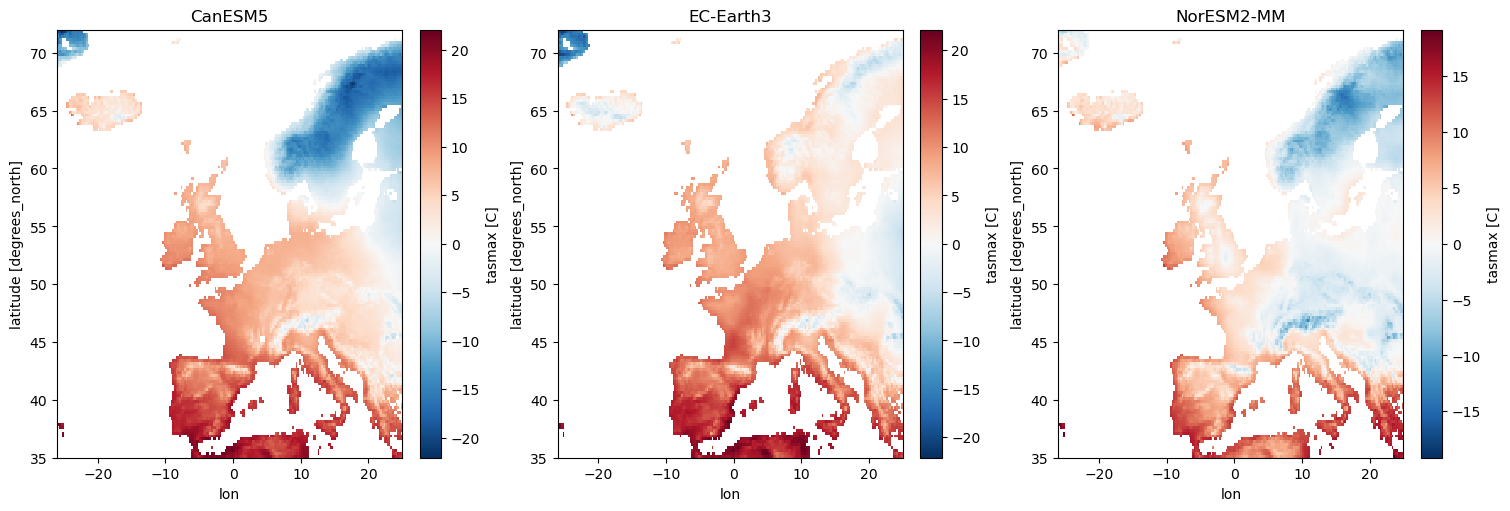

In [ ]:
# ==========================================
# Spatially visualize timestep 0 of data (manually check distribution of data)
# ==========================================

# create figure and axes to plot onto
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 5),
    constrained_layout=True
)

for ax, ds in zip(axes,datasets): 
    ds.tasmax.isel(time=0).plot(ax=ax)
    ax.set_title(ds.attrs["cmip6_source_id"])


From the maps above I inspect the data visually. I can see datasets are clipped to only land values and they all have the same spatial extent. 

In [6]:
# ==========================================
# concatenate list of datasets into single dataset for ease of use 
# ==========================================

# add model_name as a dimension in each dataset (so that they can be concatenated along that dimension)
datasets_model = [
    ds.expand_dims(model=[ds.attrs["cmip6_source_id"]])
    for ds in datasets
]

# concatenate all datasets along a 'model' dimension
ds_combined = xr.concat(
    datasets_model,
    dim="model",
    join="exact",      
    coords="minimal",
    compat="override"
)
print("======================================================")
print("Model: ",ds_combined.model)
print("Dimensions: ",ds_combined.sizes)
print("Variables: ", ds_combined.data_vars)
print("Units: ", ds_combined[list(ds_combined.data_vars)[0]].attrs["units"])


Model:  <xarray.DataArray 'model' (model: 3)> Size: 24B
array(['CanESM5', 'EC-Earth3', 'NorESM2-MM'], dtype=object)
Coordinates:
  * model    (model) object 24B 'CanESM5' 'EC-Earth3' 'NorESM2-MM'
Dimensions:  Frozen({'model': 3, 'time': 3650, 'lat': 148, 'lon': 204})
Variables:  Data variables:
    tasmax   (model, time, lat, lon) float32 1GB nan nan nan nan ... nan nan nan
Units:  C


From the prints above I am now certain that all dimensions, variable names and units match and the dataset is ready for geospatial analysis. 

## 3. Sector-specific approach to extreme heat

- Since a large share of Rabobank's portfolio is in food and agriculture, I focus the analysis on extreme heat events that are directly linked to this sector. Rabobank lists grains and oilseeds as their priority in terms of the food system's transition (https://www.rabobank.com/wholesale/industries/food-and-agriculture). Plants cannot effectively utilize nutrients and effectively grow when stressed by heat, therefore, the direct impacts of daily extreme heat on agriculture are priority in this exercise.

- According to the Rabobank Grains and Oilseeds world map 2025, EU27 production is dominated by wheat and corn. Thus, I focus on those crops on this exercise. 

- For wheat and maize, a high temperature threshold is 32°C (Schauberger et al. 2017). Corn tends to have slightly higher tolerance, so a threshold might be closer to 35°C. 32°C covers both for initial analysis. 

- I count the number of days per location per year that surpass this threshold, as well as degree-days (in which the actual degrees above the threshold matter as much as the number of days) to get a sense of extreme heat occurrences per gridcell (Xiao et al. 2025). Degree days combine the event occurrence with its intensity. I keep these two indicators as they are simple to communicate to non-technical stakeholders and are able to capture the spatial and temporal trends in potentially damaging heat conditions.

- Also outdoor labor productivity is impacted by extreme heat. From WMO: Agricultural workers are 35 times more likely to die from occupational heat exposure than all workers combined in other sectors. Temperatures above 32°C can reduce daily labour supply in exposed sectors by up to 14% (Levi et al. 2018)

### Caveats: 

- Climatology is not taken into account as it cannot be assessed with a decade of Tmax data. This should be done in a future iteration

- Absolute threshold for temperature is biased toward warmer regions, but a case can be made that crops, and humans, are sensitive to absolute temperature values and that relative (percentile-based) thresholds would be complementary to this analysis. 

- A future approach should filter events by minimum duration and merge events that are too close together in time to be independent


In [ ]:
# define the extreme-heat threshold in degrees
TEMP_THRESH = 32 #°C


### 3.1 Annual extreme heat metrics

I first calculate annual values for total heat days and heat degree days. 

In [ ]:

# heat days per year per model per gridcell (event count per year)
heat_days_annual = (
    (ds_combined.tasmax > TEMP_THRESH)  
    .resample(time="Y")                     
    .sum()                                   
    .rename("heat_days_annual")
)

# heat degree-days per year per model per gridcell (proxy of event count AND intensity)
heat_DD_annual = (                         
    (ds_combined.tasmax - TEMP_THRESH)  
    .clip(min=0)                             
    .resample(time="Y")
    .sum()
    .rename("heat_DD_annual")
)

/Users/afer/miniforge3/envs/CE_env/lib/python3.13/site-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/Users/afer/miniforge3/envs/CE_env/lib/python3.13/site-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


Then I can spatially visualize the resulting extreme heat metrics over Europe. Below, I show the average number of extreme heat days detected in each location and from all models. I also show the degree-days metric, which combines number of days with the extremety of their temperature values. 

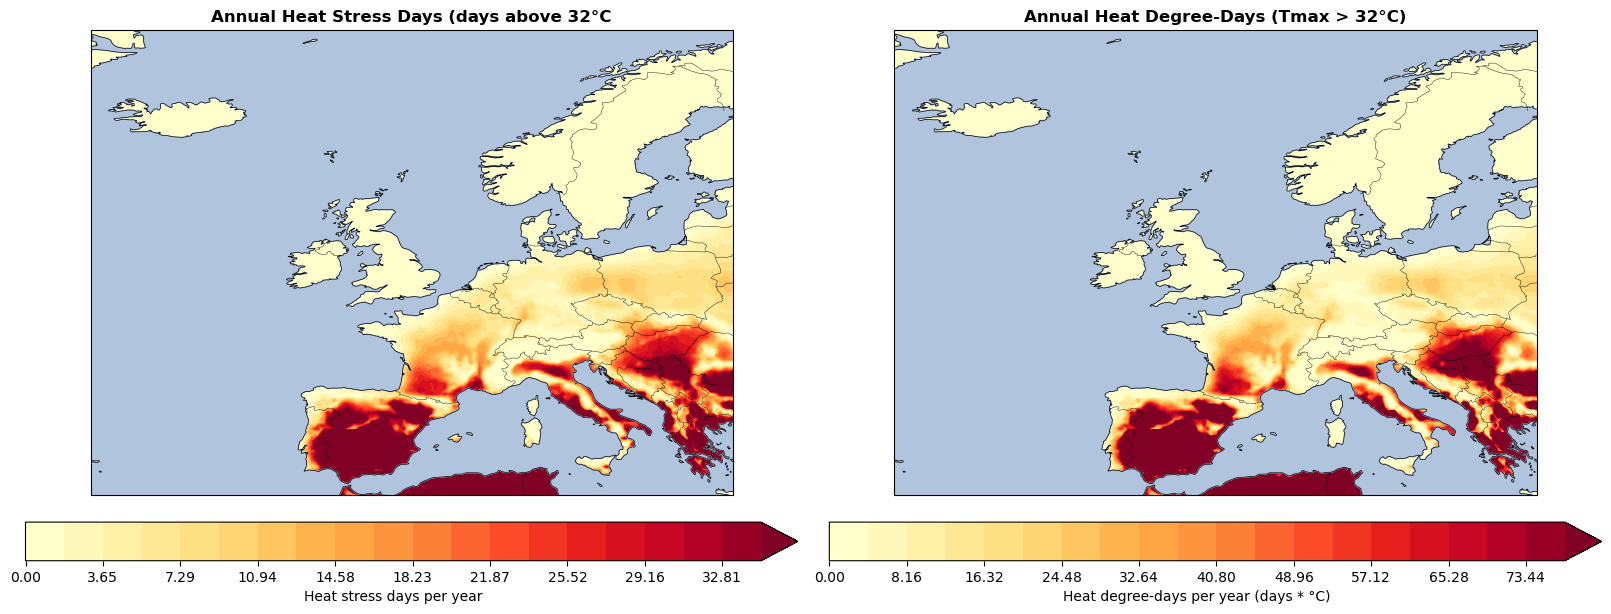

In [25]:

# ==========================================
# Compute mean across models for each metric
# "Typical" heat stress across the 2020-2029 period
# ==========================================

hd_median = heat_days_annual.mean(dim="model") # the mean captures the model spread but is susceptible to outliers. The median is also appropriate here. 
hdd_median = heat_DD_annual.mean(dim="model")  

DATA_CRS = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=1, ncols=2,
    figsize=(16, 6),
    subplot_kw={"projection": DATA_CRS},
    constrained_layout=True
)

plot_data   = [hd_median.mean(dim="time"),  hdd_median.mean(dim="time")] # I assign both metrics to a list so that I can call them in a loop for consistent plotting below
plot_labels = ["Heat stress days per year", "Heat degree-days per year (days * °C)"]
plot_titles = ["Annual Heat Stress Days (days above 32°C", "Annual Heat Degree-Days (Tmax > 32°C)"]

for ax, data, label, title in zip(axes, plot_data, plot_labels, plot_titles):

    ax.add_feature(cfeature.OCEAN,color="lightsteelblue", zorder=2)
    ax.add_feature(cfeature.LAND, color="whitesmoke",     zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3,          zorder=2)

    vmin = 0
    vmax = data.quantile(0.95).item() # cut the data off by percentile in case of heavy extreme values that may skew the color distribution
    levels = np.linspace(vmin,vmax,20)
    norm = PowerNorm(gamma=1.0, vmin=vmin, vmax=vmax) # possible to apply a power normalization to avoid heavily skewed maps (set to gamma=1.0 for standard, linearly normalized colormap)
    im = data.plot.contourf(
        ax=ax,
        transform=DATA_CRS,
        cmap="YlOrRd",
        add_colorbar=False,
        zorder=1,
        levels=levels,
        norm=norm
    )

    cbar = fig.colorbar(im, ax=ax, orientation="horizontal")
    cbar.set_label(label, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")


The maps above show the spatial variability in captured extreme heat days. However, they are not very helpful as the colormaps are dominated by warm Mediterranean climates. I can now explore single locations, which may be more informative as local climatology is constant. 

### 3.2 Specific location visualizations and assessment of uncertainty

After observing the spatial variability in number of extreme heat days, I focus on a few specific locations and showcase the temporal evolultion of these events captured per model and per year, as well as the overall variability between models using box-whisker plots. 

Text(0.5, 0.98, 'Annual heat degree-days (intensity and amount of extreme heat) for selected locations')

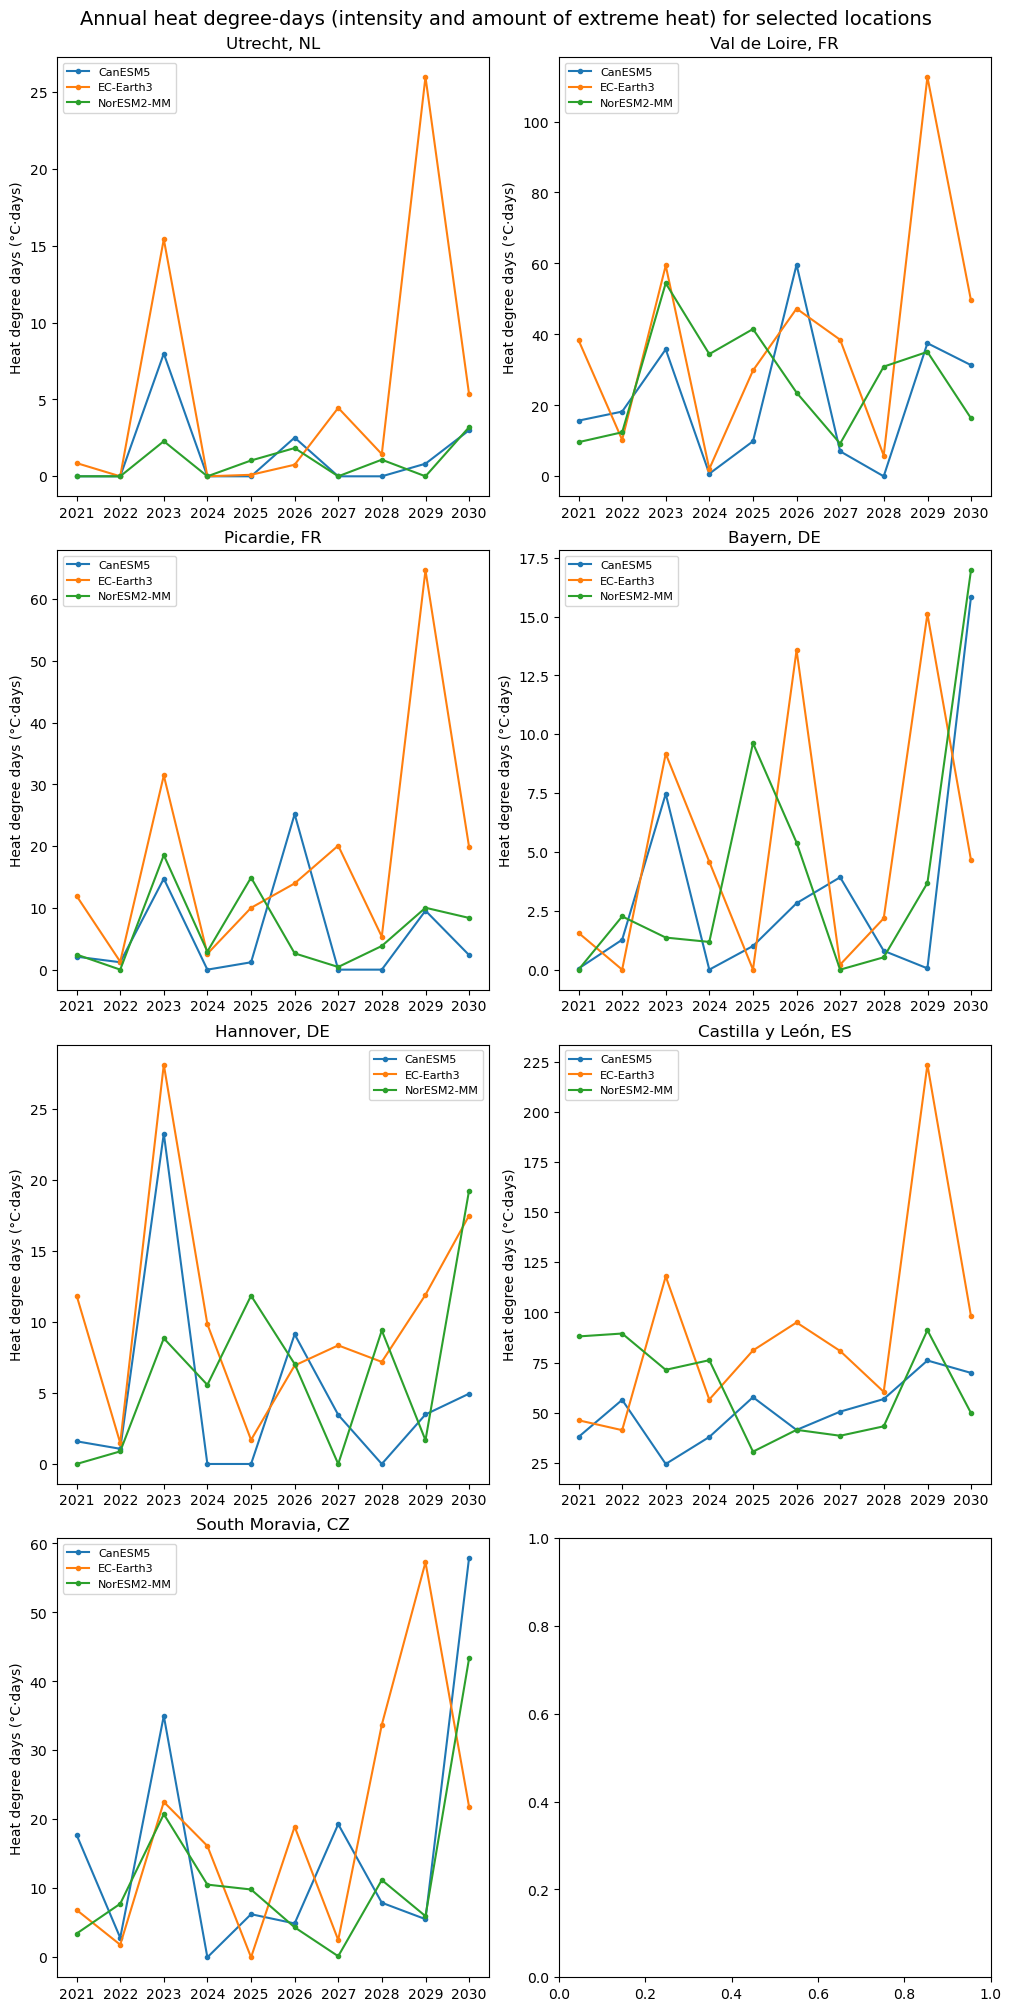

In [31]:
# ===============================================
# I pick regions based on top producers of wheat across Europe, according to the USDA
# ===============================================

# according to USDA, some top producing regions of wheat: https://www.fas.usda.gov/data/production/0410000

locations = {
    "Utrecht, NL":{"lat": 52.1,  "lon": 5.1}, # Rabobank's HQ
    "Val de Loire, FR":{"lat": 47.5,  "lon": 1.5},
    "Picardie, FR":{"lat": 49.8,  "lon": 2.8},
    "Bayern, DE":{"lat": 48.5,  "lon": 11.5},
    "Hannover, DE": {"lat": 52.4,  "lon": 9.7},
    "Castilla y León, ES":{"lat": 41.5,  "lon": -4.5},
    "South Moravia, CZ":{"lat": 49,  "lon": 16.3},
}

# extract data for each location
location_data = {}
for name, coords in locations.items():
    da = heat_DD_annual.sel(
        lat=coords["lat"],
        lon=coords["lon"],
        method="nearest"   
    )                      
    location_data[name] = da

# ==================================================
# Plot simple time series to osberve how specific locations evolve through time
# =================================================== 

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(10, 20),
    constrained_layout=True
)

axes_flat = axes.flatten() 

for ax, (loc_name, da) in zip(axes_flat, location_data.items()):
    for model in da.model.values:
        da.sel(model=model).plot(ax=ax, label=model, marker="o", markersize=3)
    ax.set_title(loc_name)
    ax.set_ylabel("Heat degree days (°C·days)")
    ax.set_xlabel("")
    ax.legend(fontsize=8)

fig.suptitle("Annual heat degree-days (intensity and amount of extreme heat) for selected locations", fontsize=14)

These timeseries show the relative variability between models for each location. They are not very good, however, at showing how much different each place is to each other (note the values in the Y-axis). To observe this, we plot inter-model variability for ALL years in each location: 

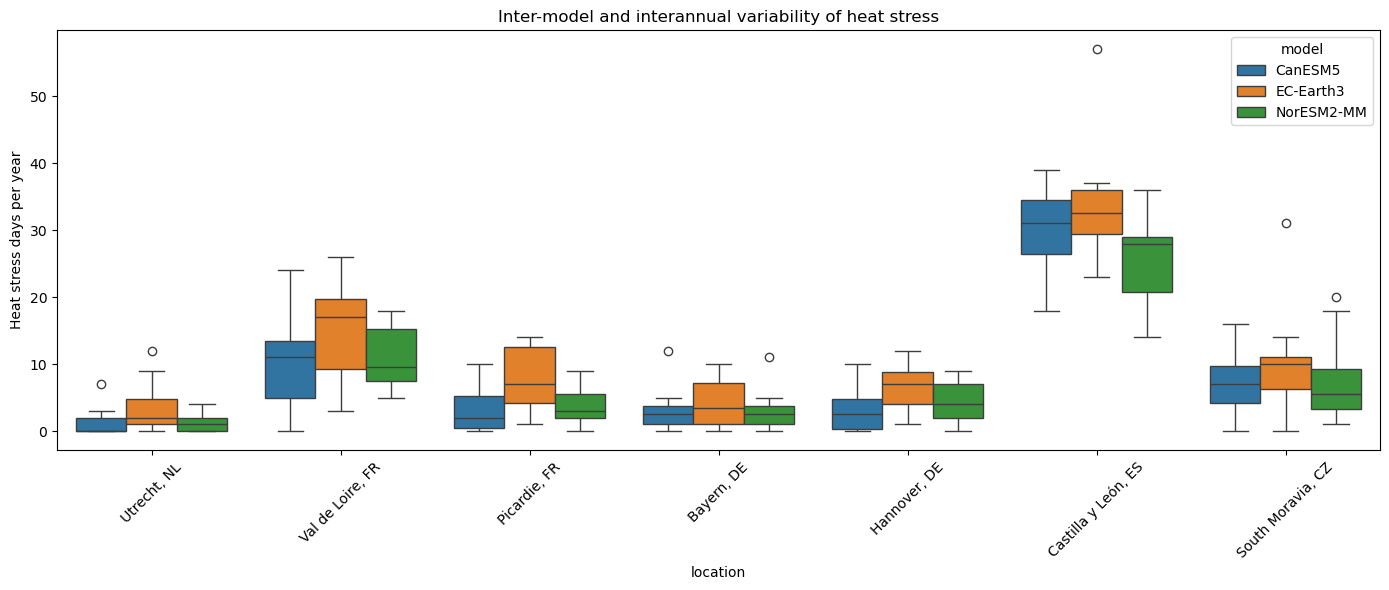

In [32]:

# ===============================================
# I extract the necessary data from the event identification above
# ===============================================

# extract data for each location and model combination
location_data = {}
for name, coords in locations.items():
    da = heat_days_annual.sel(
        lat=coords["lat"],
        lon=coords["lon"],
        method="nearest"   
    )                      
    location_data[name] = da

# transfer data to pandas dataframe for easier plotting
records = []

for loc_name, da in location_data.items():
    
    df = da.to_dataframe().reset_index()

    df["location"] = loc_name

    records.append(df)

df_all = pd.concat(records)

# ===============================================
# plot the spread per location and per model for each year in the dataset
# ===============================================

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df_all,
    x="location",
    y="heat_days_annual",
    hue="model"
)
plt.xticks(rotation=45)
plt.ylabel("Heat stress days per year")
plt.title("Inter-model and interannual variability of heat stress")
plt.tight_layout()


Now we can see the spread from different models (note how EC-Earth tends to capture more events in most of the locations), as well as the relative number of events in each place (Spain dominates and Utrecht barely experiences extreme heat)

### 3.3 Trend analysis

Finally, I am interested in whether there is a detectable level of change in the data due to climate change. I perform a simple linear trend analysis on the extreme heat day counts to see whether they look to be increasing. It should be noted that 10 years is relatively short in climate timescales and therefore this test is not entirely telling of any specific trend, but more to assess whether such a trend is detectable or not. 


Text(0.5, 1.0, 'Trend analysis of annual extreme heat over Europe, 2020-2030')

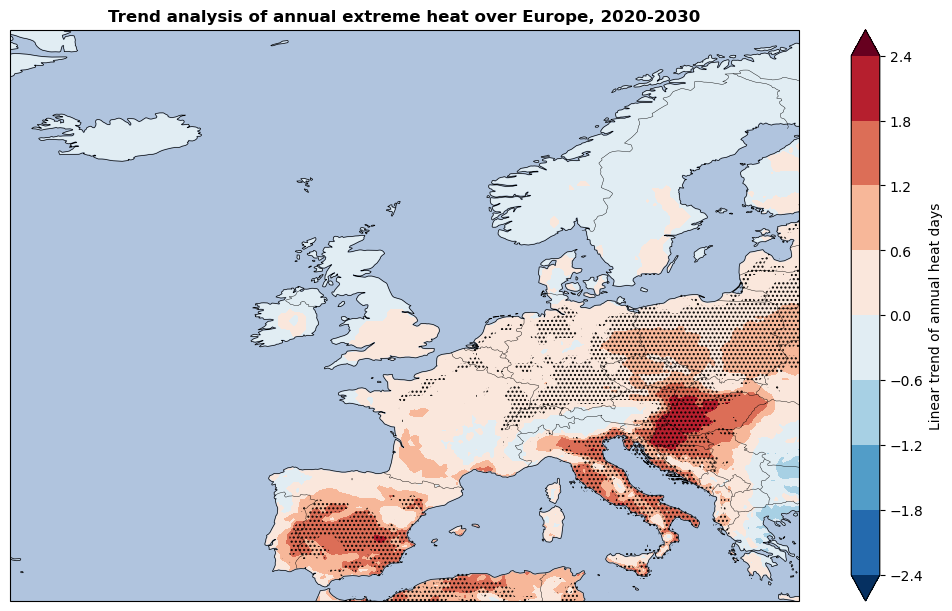

In [33]:
# =========================================
# first change 'time' dimension into year values, instead of cftime, so that slope results are in correct units
# =========================================


heat_days_annual_yr = heat_days_annual.assign_coords(
    year=heat_days_annual.time.dt.year
)

heat_days_annual_yr["time"] = heat_days_annual_yr["year"]


# Apply polyfit along the time (year) dimension for each model
trend = heat_days_annual_yr.polyfit(dim='time', deg=1, full=False) # this is a linear (deg = 1) trend fit
slopes = trend['polyfit_coefficients'].sel(degree=1) # obtain the slope values for each location and model 

# Take the mean across the 'model' dimension 
mean_slope = slopes.mean(dim='model')

# obtain spatial mask where all models agree on positive slope, so that we can assess level of certainty
positive_slope_mask = (slopes.min(dim='model') > 0) 

# =========================================
# plot trend analysis map with stippling where all models agree on positive slope
# =========================================
DATA_CRS = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize = (12,6),
    subplot_kw = {"projection":DATA_CRS},
    constrained_layout=True
)

ax.add_feature(cfeature.OCEAN, color="lightsteelblue", zorder=2)
ax.add_feature(cfeature.LAND, color="whitesmoke",     zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.3,          zorder=2)

# trend map
im = mean_slope.plot.contourf(
    ax=ax,
    transform=DATA_CRS,
    cmap="RdBu_r",
    levels=10,
    add_colorbar=False,
    extend="both",
    zorder=1
)
# stippling where all models agree on positive slope
ax.contourf(
    mean_slope.lon,
    mean_slope.lat,
    positive_slope_mask,
    levels=[0.9, 1.1],
    hatches=["...."],
    colors="none",
    transform=DATA_CRS,
    zorder=3
)

cbar = fig.colorbar(im, ax=ax, orientation="vertical")
cbar.set_label("Linear trend of annual heat days")
ax.set_title("Trend analysis of annual extreme heat over Europe, 2020-2030", fontsize=12, fontweight="bold")


In the map above, I show that the Iberian peninsula, the italian peninsula and eastern Europe have significant trends for the decade of 2020 to 2030 of increasing annual heat days of up to 2.5 (i.e., 2.5 more days of extreme heat per year on average across 3 models). Areas with no stippling may show increasing or decreasing trends but the uncertainty across models is large. 

## 4. Remarks and conclusions

Future assessments of extreme heat should take into account each location's climatology, as a heat event in Spain is not the same level of impactful as it would be in Scandinavia. Additionally, a decade of data is useful to visualize current conditions, but climate non-stationarity means we are measuring statistics over changing conditions due to anthropogenic climate change. 

Specific crops, or health concerns, could inform future analyses to constrain assumptions and thresholds, and allow for more specific indexes to be utilized. 

## References

### Peer-reviewed literature

- Schauberger B, Gornott C, Wechsung F. Global evaluation of a semiempirical model for yield anomalies and application to within-season yield forecasting. Glob Change Biol. 2017;23:4750–4764. https://doi.org/10.1111/gcb.13738

- Xiao, K., Zhou, X., Gui, H., Tian, Y., Chen, X., Li, Y., et al. (2025). Drought and extreme heat reduce wheat and maize production in the United States by lowering both crop yields and harvestable fraction. Earth's Future, 13, e2024EF005557. https://doi.org/10.1029/2024EF005557

- Levi M, Kjellstrom T, Baldasseroni A. Impact of climate change on occupational health and productivity: a systematic literature review focusing on workplace heat. Med Lav. 2018 Apr 24;109(3):163-79. doi: 10.23749/mdl.v109i3.6851. PMID: 29943748; PMCID: PMC7689800.


### Online resources
- https://media.rabobank.com/m/53d23b1468120ed4/original/Grains-Oilseeds-World-Map-2025.pdf

- https://wmo.int/media/news/fao-and-wmo-report-highlights-extreme-heat-risks-agriculture

- https://www.rabobank.com/wholesale/industries/food-and-agriculture



